In [2]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library(CCA)
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)
library(corrplot)
library(ggrepel)


theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

Warning message:
“package ‘DESeq2’ was built under R version 4.2.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.2.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.2.1”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    exp

In [3]:
tpm<- read.table('../data/7_mature_rna_tss_tpm_norm_by_deseq2.tsv', header=T, sep="\t", row.names=1, check.names = FALSE)
colnames(tpm) = paste0(rep(c("WT", "MUT"), each = 3), c("_rep1", "_rep2", "_rep3")) 

In [4]:
df<- read.table("../data/11_isoform_and_chromatin_state_usage_combined.tsv", header = T, row.names = 1, sep = "\t", check.names = F)

In [5]:
dominance_threshold = 0.3
mcol <- rev(c("#ca0020", "#f4a582", "#92c5de"))
names(mcol) <- c("low", "medium", "high")

In [6]:
chrom_level = c('promoter-accessible', 'intragenic-accessible', 'co-accessible', 'fully-nucleosomal', 'fully-accessible')

## Low expression genes

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


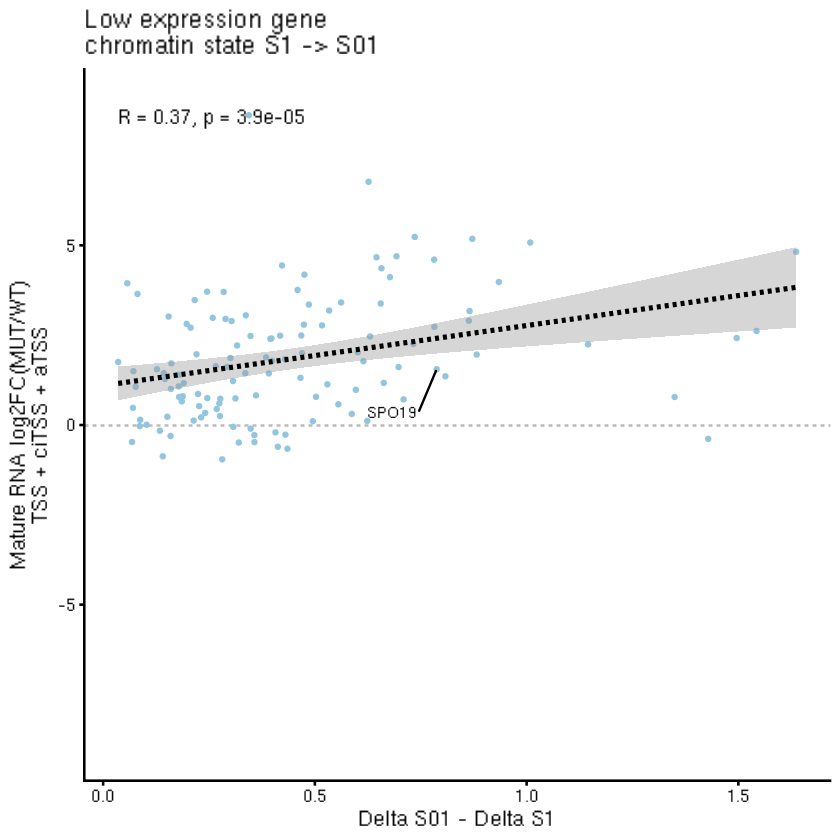

In [7]:
down_state = c('fully-nucleosomal')
up_state = c('promoter-accessible')

candidates <- df %>%
    filter(
        if_any(all_of(down_state), ~ .x < 0),
        if_any(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = lfc_tss +lfc_citss + lfc_atss , 
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(shift_score)) %>%
    filter(dominance >= dominance_threshold) %>% filter(class == 'low')

label_gene<- candidates["SPO19",]

candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey') +
    geom_point(aes(color = class), size = 0.7) +
    labs(x = 'Delta S01 - Delta S1',  y = 'Mature RNA log2FC(MUT/WT)\nTSS + ciTSS + aTSS', 
         title = 'Low expression gene\nchromatin state S1 -> S01') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman", label.x.npc = "left", label.y.npc = "top", size = 4) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel( data = label_gene, aes(label = geneid), size = 3, box.padding = 1.5, max.overlaps = 3) +
    theme(legend.position = "none")  +
    ylim(-9, 9)

ggsave('../figures/Figure3_correlation_chromain_isoform_low_expr.pdf', width = 4, height = 3)

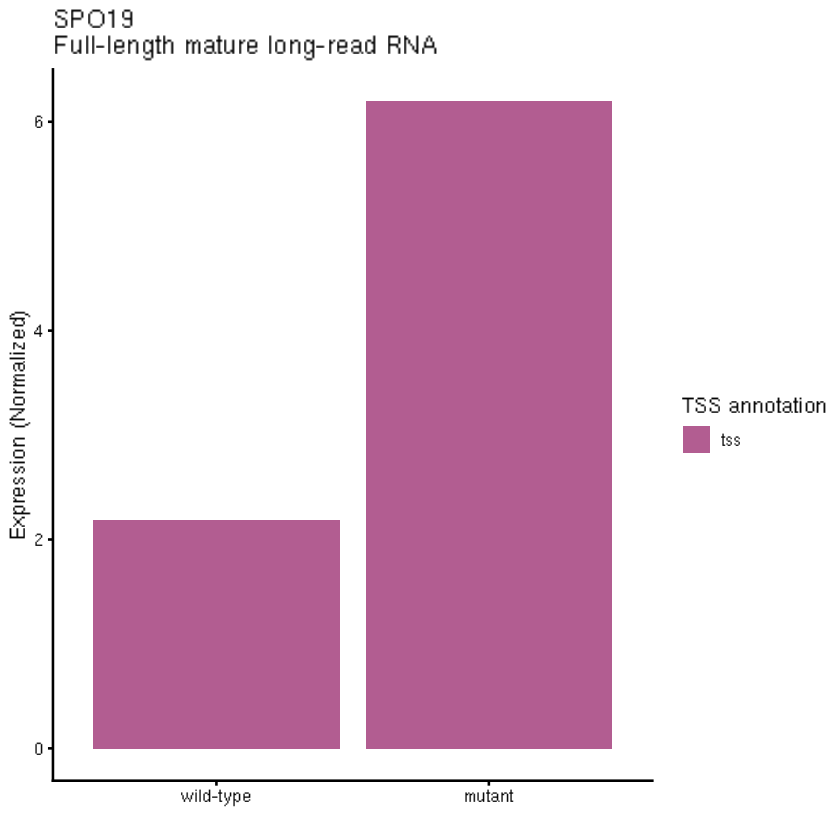

In [8]:
plot_expr_telo(tpm, "SPO19")
ggsave('../figures/Figure3_SPO19_cpm.pdf', width = 5, height = 3)

## medium expression genes

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


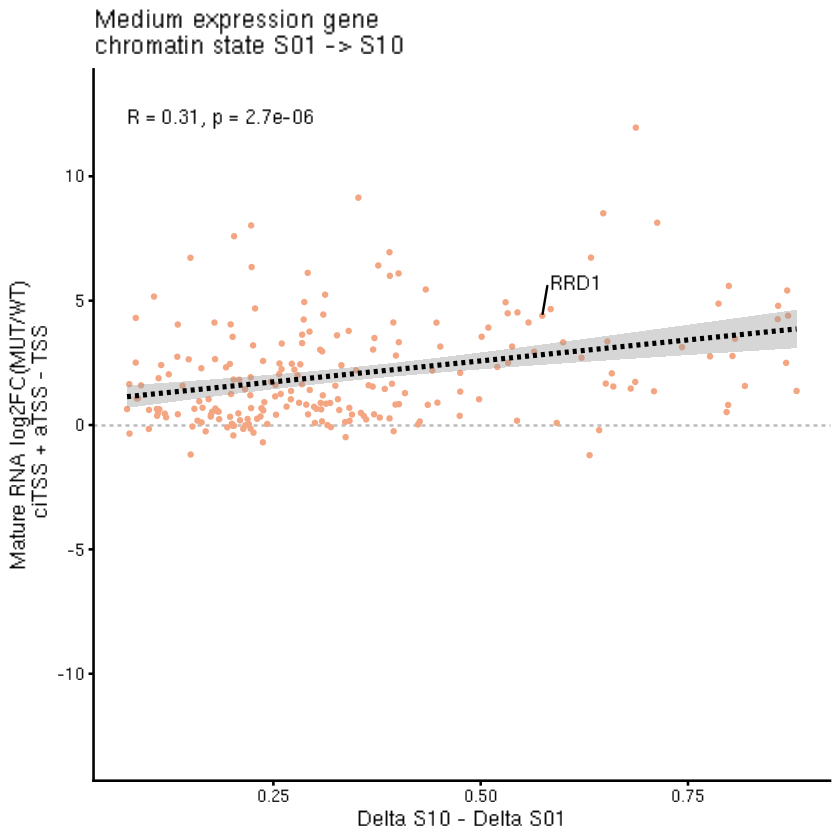

In [9]:
down_state = c('promoter-accessible')
up_state = c('intragenic-accessible')

candidates <- df %>%
    filter(
        if_any(all_of(down_state), ~ .x < 0),
        if_any(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = lfc_citss + lfc_atss - lfc_tss,
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(shift_score)) %>%
    filter(dominance >= dominance_threshold)  %>% filter(class == 'medium')

label_gene<- candidates["RRD", ]

candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey') +
    geom_point(aes(color = class), size = 0.7) +
    labs(x = 'Delta S10 - Delta S01',  y = 'Mature RNA log2FC(MUT/WT)\n ciTSS + aTSS - TSS', 
         title = 'Medium expression gene\nchromatin state S01 -> S10') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman",
             label.x.npc = "left", label.y.npc = "top", size = 4) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel(
        data = label_gene,
        aes(label = geneid), size = 4, box.padding = 1) +
    theme(legend.position = "none") +
    ylim(-13, 13)

ggsave('../figures/Figure3_correlation_chromain_isoform_medium_expr.pdf', width = 4, height = 3)

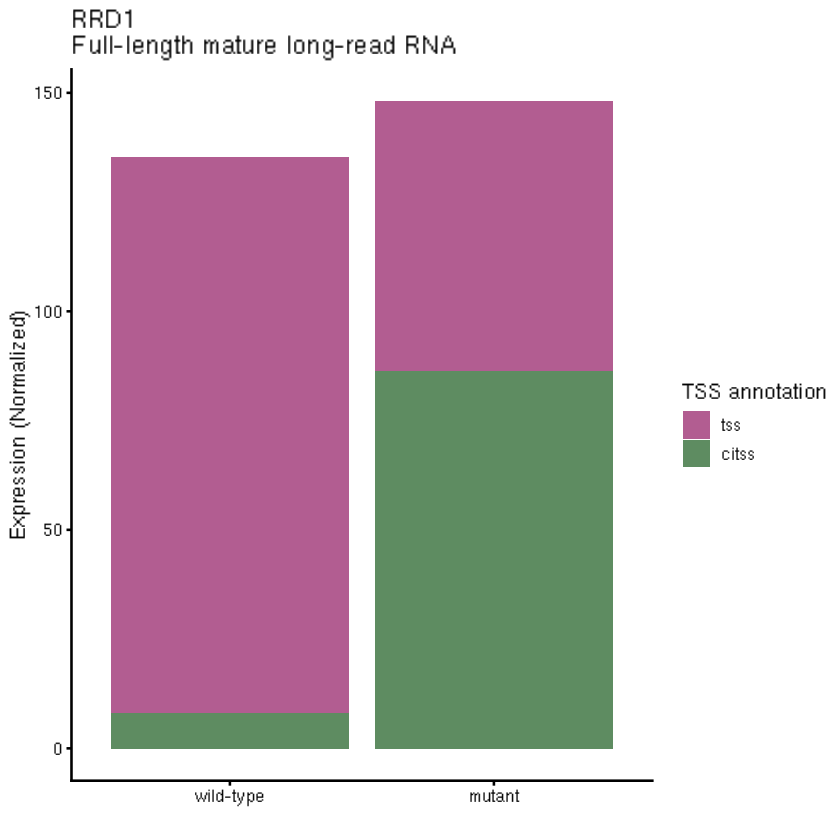

In [10]:
plot_expr_telo(tpm, "RRD1")
ggsave('../figures/Figure3_RRD1_cpm.pdf', width = 5, height = 3)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


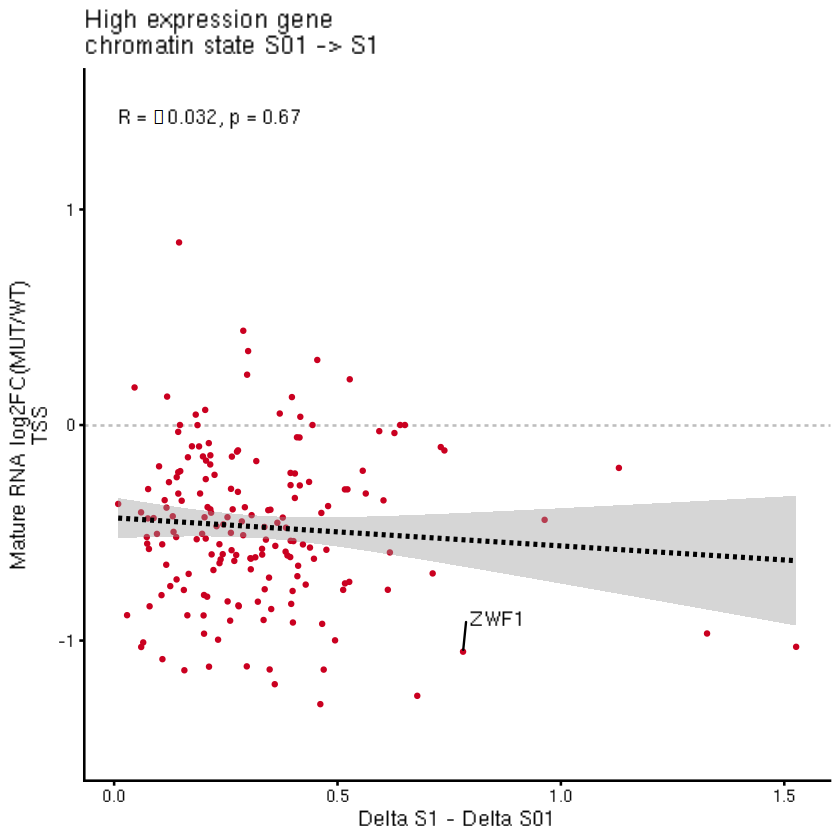

In [17]:
down_state = c('promoter-accessible')
up_state = c('fully-nucleosomal')

candidates <- df %>%
    filter(
        if_any(all_of(down_state), ~ .x < 0),
        if_any(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = lfc_tss,
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(shift_score)) %>%
    filter(dominance >= dominance_threshold) %>% filter(class == 'high')

label_gene<- candidates["ZWF1", ]


candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey') +
    geom_point(aes(color = class), size = 0.7) +
    labs(x = 'Delta S1 - Delta S01',  y = 'Mature RNA log2FC(MUT/WT)\nTSS', 
         title = 'High expression gene\nchromatin state S01 -> S1') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman", label.x.npc = "left", label.y.npc = "top", size = 4) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel(
        data = label_gene,
        aes(label = geneid), size = 4, box.padding = 1) +
    theme(legend.position = "none") +
    ylim(-1.5, 1.5)

ggsave('../figures/Figure3_correlation_chromain_isoform_high_expr.pdf', width = 4, height = 3)

In [18]:
candidates %>% arrange(shift_score_iso)

,promoter-accessible,intragenic-accessible,co-accessible,fully-nucleosomal,fully-accessible,class,lfc_tss,lfc_citss,lfc_atss,WT_mean_co-accessible,⋯,WT_mean_tss,MUT_mean_atss,MUT_mean_citss,MUT_mean_tss,shift_score,shift_score_iso,total_abs_change,target_abs_change,dominance,geneid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
RAS2,-0.33006969,0.16004818,-0.0403519591,0.131467338,0.078906129,high,-1.2949972,0.0000000,1.867744,0.09929787,⋯,0.9796361,5.575776e-02,0.023022296,0.9212199,0.46153702,-1.2949972,0.74084329,0.46153702,0.6229887,RAS2
FPR3,-0.46004564,0.07937216,0.1202040895,0.218479956,0.041989436,high,-1.2563386,-1.1262814,2.079250,0.13334963,⋯,0.9433326,1.754746e-02,0.057833182,0.9246194,0.67852559,-1.2563386,0.92009128,0.67852559,0.7374547,FPR3
RPP1A,-0.29584106,0.00000000,0.1578639857,0.063695765,0.074281311,high,-1.2025460,-0.6695917,0.000000,0.10153851,⋯,0.9978509,9.908733e-04,0.003020537,0.9959886,0.35953683,-1.2025460,0.59168212,0.35953683,0.6076520,RPP1A
HXT1,-0.14601675,0.00000000,0.1476828406,0.011224152,-0.012890241,high,-1.1378025,-0.6918130,0.000000,0.07651932,⋯,0.9798210,2.874195e-03,0.027521366,0.9696044,0.15724090,-1.1378025,0.31781399,0.15724090,0.4947577,HXT1
ADE13,-0.27376196,0.00000000,0.0521111158,0.195356366,0.026294476,high,-1.1347058,-0.7649755,0.000000,0.07262007,⋯,0.9769137,5.996410e-03,0.024507484,0.9694961,0.46911832,-1.1347058,0.54752392,0.46911832,0.8567997,ADE13
NSG1,-0.23286409,0.00000000,0.0535469773,0.115265580,0.064051536,high,-1.1341337,0.0000000,0.000000,0.08289294,⋯,1.0000000,0.000000e+00,0.054166667,0.9458333,0.34812967,-1.1341337,0.46572819,0.34812967,0.7474954,NSG1
SPE3,-0.13017617,0.00000000,0.0384695900,0.082210523,0.009496052,high,-1.1211909,0.9475658,0.000000,0.13601589,⋯,0.9827800,4.025507e-03,0.055782330,0.9401922,0.21238669,-1.1211909,0.26035233,0.21238669,0.8157664,SPE3
MIG2,-0.20246749,0.00000000,0.0277212987,0.094477374,0.080268821,high,-1.1197152,0.0000000,0.000000,0.17050482,⋯,0.9864745,2.163706e-02,0.025332164,0.9530308,0.29694487,-1.1197152,0.40493499,0.29694487,0.7333149,MIG2
YKL033W-A,-0.07287544,0.00000000,0.0147284892,0.035235996,0.022910951,high,-1.0862421,0.0000000,1.519075,0.18697117,⋯,0.9897887,2.560196e-02,0.016716580,0.9576815,0.10811143,-1.0862421,0.14575087,0.10811143,0.7417550,YKL033W-A


In [26]:
count<- read.table('../data/7_mature_rna_tss_count.tsv', header=T, sep="\t", row.names=1, check.names = FALSE)

In [28]:
colSums(count)

WT rep1  WT rep2  WT rep3 MUT rep1 MUT rep2 MUT rep3 
 1542657  1296572  1179930  2306338  3799288  1910420

In [37]:
count[grep(x = rownames(count), pattern = "ZWF1"),]

,WT rep1,WT rep2,WT rep3,MUT rep1,MUT rep2,MUT rep3
,<int>,<int>,<int>,<int>,<int>,<int>
ZWF1:atss_ZWF1,2,0,1,5,7,3
ZWF1:citss_ZWF1,8,7,6,16,31,19
ZWF1:tss_ZWF1,218,302,169,246,594,136


In [36]:
(count[grep(x = rownames(count), pattern = "ZWF1"),]*10e6)/colSums(count)

,WT rep1,WT rep2,WT rep3,MUT rep1,MUT rep2,MUT rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ZWF1:atss_ZWF1,12.96464,0.0000,6.482322,21.67939,45.37626,13.00763
ZWF1:citss_ZWF1,61.70116,18.4245,46.275872,42.11315,239.09201,50.00937
ZWF1:tss_ZWF1,1847.56723,1580.8042,1432.288356,1287.67496,5034.19694,711.88534


In [23]:
tpm[grep(x = rownames(tpm), pattern = "ZWF1"),]

,WT_rep1,WT_rep2,WT_rep3,MUT_rep1,MUT_rep2,MUT_rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ZWF1:citss_ZWF1,10.6229,12.01038,10.7738,10.81422,13.33432,15.63021
ZWF1:tss_ZWF1,289.4740,518.16194,303.4622,166.26862,255.50281,111.87939


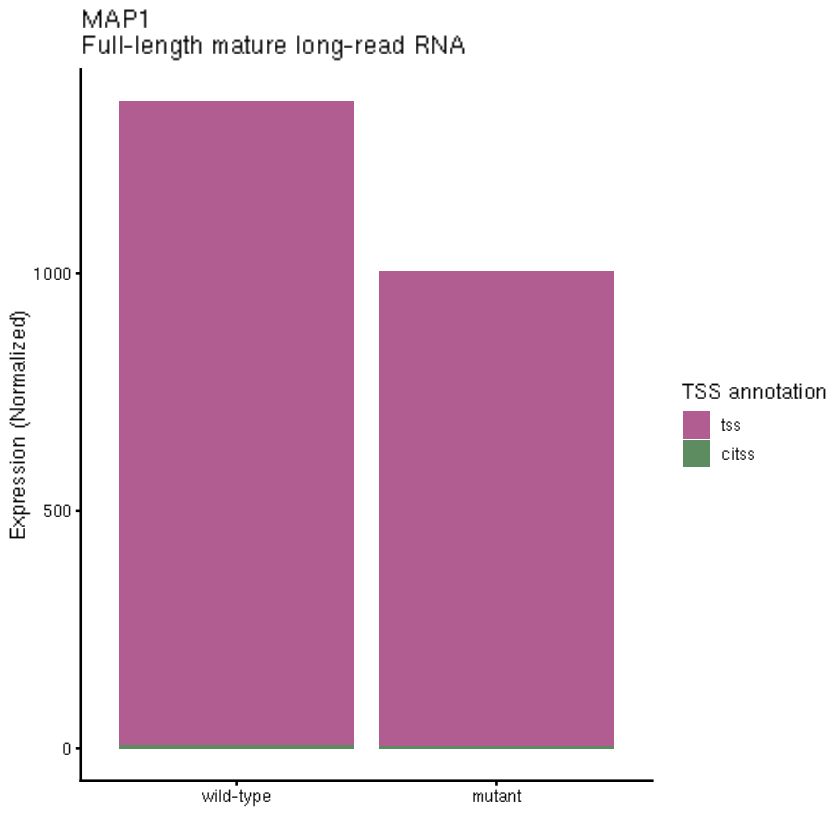

In [12]:
plot_expr_telo(tpm, "MAP1")
ggsave('../figures/Figure3_MAP1_cpm.pdf', width = 5, height = 3)

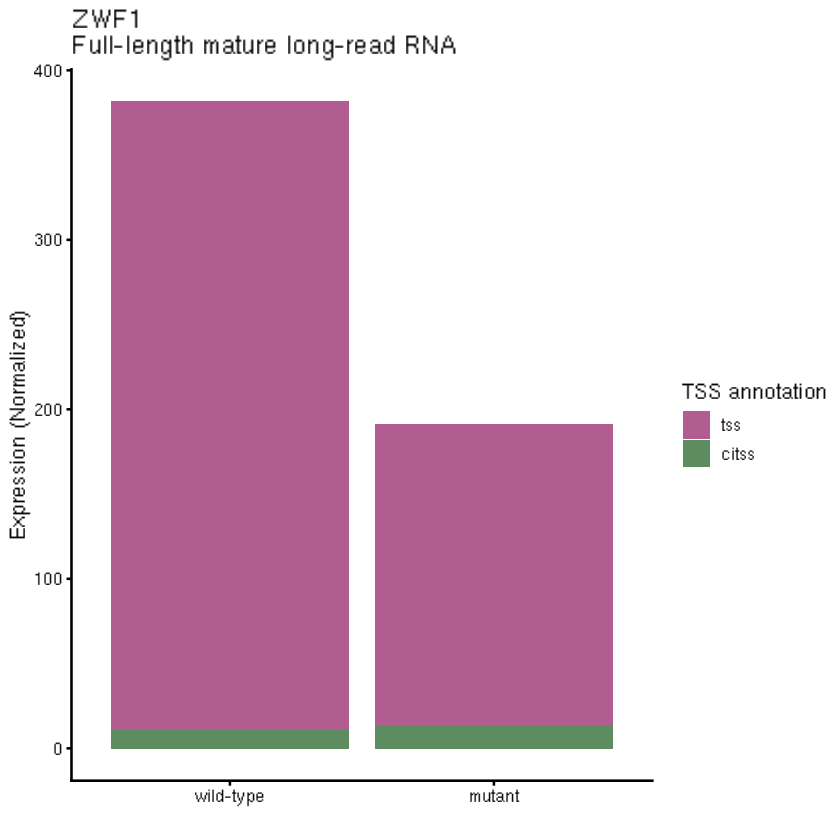

In [16]:
plot_expr_telo(tpm, "ZWF1")
ggsave('../figures/Figure3_ZWF1_cpm.pdf', width = 5, height = 3)